# Sports Ball Classification Using Support Vector Machines
This program classifies images of sports balls using a Support Vector Machine (SVM) model. It loads images from a dataset where each class of ball (e.g., football, basketball) is stored in labeled folders. The images are resized and flattened into 1D feature vectors, then split into training and testing sets. The SVM model is trained on these features to classify each ball type based on its pixel data.

## Loading the dataset
The following aproach assumes that the dataset folder "archive (sport Balls)" is always in "Project" folder which is a sibling of the "Notebooks" folder.

In [1]:
import os
import cv2  # for image processing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder


# Get the current notebook directory
notebook_dir = os.getcwd()
# Navigate to the "Project" folder)
project_dir = os.path.join(os.path.dirname(notebook_dir), 'Project')
# Construct paths to the dataset
dataset_dir = os.path.join(project_dir, 'archive (sport Balls)')
train_path = os.path.join(dataset_dir, 'train')
test_path = os.path.join(dataset_dir, 'test')
# Print the paths for verification
print(f"notebook_dir: {notebook_dir}")
print(f"Project_dir: {project_dir}")
print(f"Training path: {train_path}")
print(f"Testing path: {test_path}")

notebook_dir: C:\Users\badri\Introduction-to-AI-Group-14-\Notebooks
Project_dir: C:\Users\badri\Introduction-to-AI-Group-14-\Project
Training path: C:\Users\badri\Introduction-to-AI-Group-14-\Project\archive (sport Balls)\train
Testing path: C:\Users\badri\Introduction-to-AI-Group-14-\Project\archive (sport Balls)\test


In [3]:
image_size = (64, 64)  # Resize images for consistency

# preparing the dataset by loading the images and their labels from the dataset folder structure.
def load_images_from_folder(folder_path):
    #Initialise empty lists
    images = []
    labels = []
    #Loop through folders
    for label in os.listdir(folder_path):
        #create the path to the current subfolder
        label_path = os.path.join(folder_path, label)
        #Check if it’s a folder
        if os.path.isdir(label_path):  # Skip non-directory files if any
            #Loop through each image in the subfolder
            for filename in os.listdir(label_path):                
                img_path = os.path.join(label_path, filename) #For each file in the subfolder
                image = cv2.imread(img_path) # loads the image into memory using OpenCV.
                #Store valid images
                if image is not None: #checks if the image was loaded successfully.
                    image = cv2.resize(image, image_size)  # Resize to (64, 64)
                    images.append(image)
                    labels.append(label)                    
    return np.array(images), np.array(labels)

# Load images
print("Loading training data...")
train_images, train_labels = load_images_from_folder(train_path)
print("Loading testing data...")
test_images, test_labels = load_images_from_folder(test_path)

# Check shapes
print("Train image shapes:", {img.shape for img in train_images})
print("Test image shapes:", {img.shape for img in test_images})


Loading training data...
Loading testing data...
Train image shapes: {(64, 64, 3)}
Test image shapes: {(64, 64, 3)}


In [4]:
# Flatten images
train_images = train_images.reshape(len(train_images), -1)
test_images = test_images.reshape(len(test_images), -1)

# Scale features for PCA
scaler = StandardScaler()
train_images_scaled = scaler.fit_transform(train_images)
test_images_scaled = scaler.transform(test_images)

# Apply PCA
print("Applying PCA...")
pca = PCA(n_components=0.95)  # Retain 95% of the variance
train_images_pca = pca.fit_transform(train_images_scaled)
test_images_pca = pca.transform(test_images_scaled)

print(f"Number of PCA components: {pca.n_components_}")

# Convert the text labels (ball types) to numerical format using LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

Applying PCA...
Number of PCA components: 916


## Hyperparameter optimization
Hyperparameter optimization is performed using GridSearchCV, which systematically searches through all possible combinations of C, gamma, and kernel parameters.Each combination is assessed using 5-fold cross-validation, and the best set of hyperparameters is determined based on cross-validation accuracy.

In [21]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [1, 10, 20, 50],
    'degree': [4, 5, 6],
    'gamma': ['scale'],
    'coef0': [1, 2]
}

# Create GridSearchCV object
grid_search = GridSearchCV(SVC(kernel='poly'), param_grid, cv=5, scoring='accuracy',n_jobs=-1, verbose = 1)
grid_search.fit(train_images_pca, train_labels_encoded)

# Get best parameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate the best model
best_model = grid_search.best_estimator_
test_predictions = best_model.predict(test_images_pca)
accuracy = accuracy_score(test_labels_encoded, test_predictions)
print(f"Test Accuracy with Best Model: {accuracy * 100:.2f}%")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 1, 'coef0': 1, 'degree': 5, 'gamma': 'scale'}
Test Accuracy with Best Model: 49.59%


In [23]:
# Initialize and train the SVM classifier
print("Training SVM...")
svm_model = SVC(kernel='poly', C=1, degree=5, gamma='scale', coef0=1)  
svm_model.fit(train_images_pca, train_labels_encoded)

# Predict on test data
print("Evaluating the model...")
test_predictions = svm_model.predict(test_images_pca)

# Calculate accuracy
accuracy = accuracy_score(test_labels_encoded, test_predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print(classification_report(test_labels_encoded, test_predictions, target_names=label_encoder.classes_))


Training SVM...
Evaluating the model...
Accuracy: 49.59%
                   precision    recall  f1-score   support

american_football       0.50      0.50      0.50        96
         baseball       0.34      0.48      0.40       100
       basketball       0.40      0.42      0.41        86
    billiard_ball       0.53      0.51      0.52       162
     bowling_ball       0.44      0.45      0.45       111
     cricket_ball       0.53      0.52      0.52       146
         football       0.49      0.49      0.49       151
        golf_ball       0.41      0.49      0.45       138
      hockey_ball       0.47      0.48      0.47       133
      hockey_puck       0.51      0.42      0.46        98
       rugby_ball       0.62      0.61      0.62       124
      shuttlecock       0.55      0.51      0.53       108
table_tennis_ball       0.48      0.57      0.52       156
      tennis_ball       0.67      0.59      0.62       123
       volleyball       0.62      0.31      0.41       10

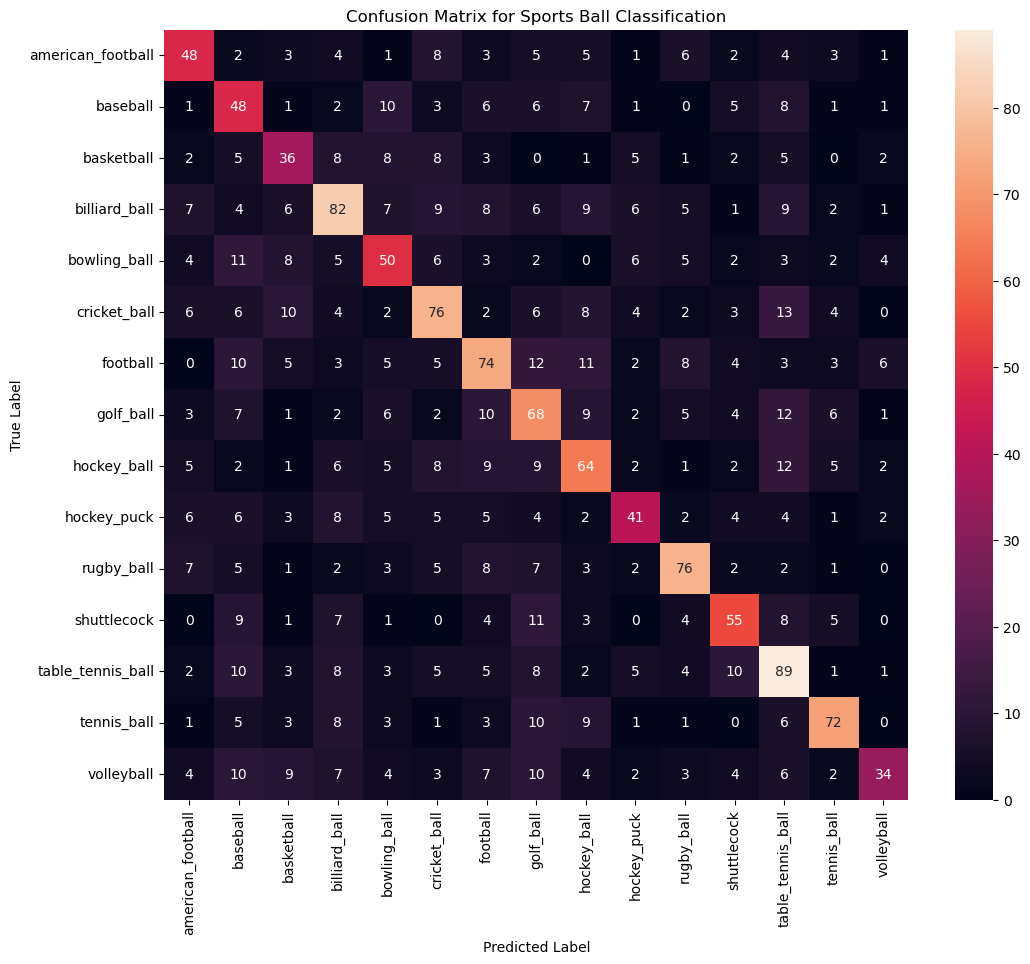

In [24]:
# Generate confusion matrix
conf_matrix = confusion_matrix(test_labels_encoded, test_predictions)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Sports Ball Classification")
plt.show()

### Class Distribution in Training and Test Sets
The following plot shows how many images are present for each class (ball type) in the training and test sets.
It helps to check for class balance. If certain ball types are underrepresented, the model might struggle to learn to classify those types correctly, leading to poor performance or bias towards more frequent classes. Identifying this early allows to take steps like collecting more images or applying techniques to balance the dataset.

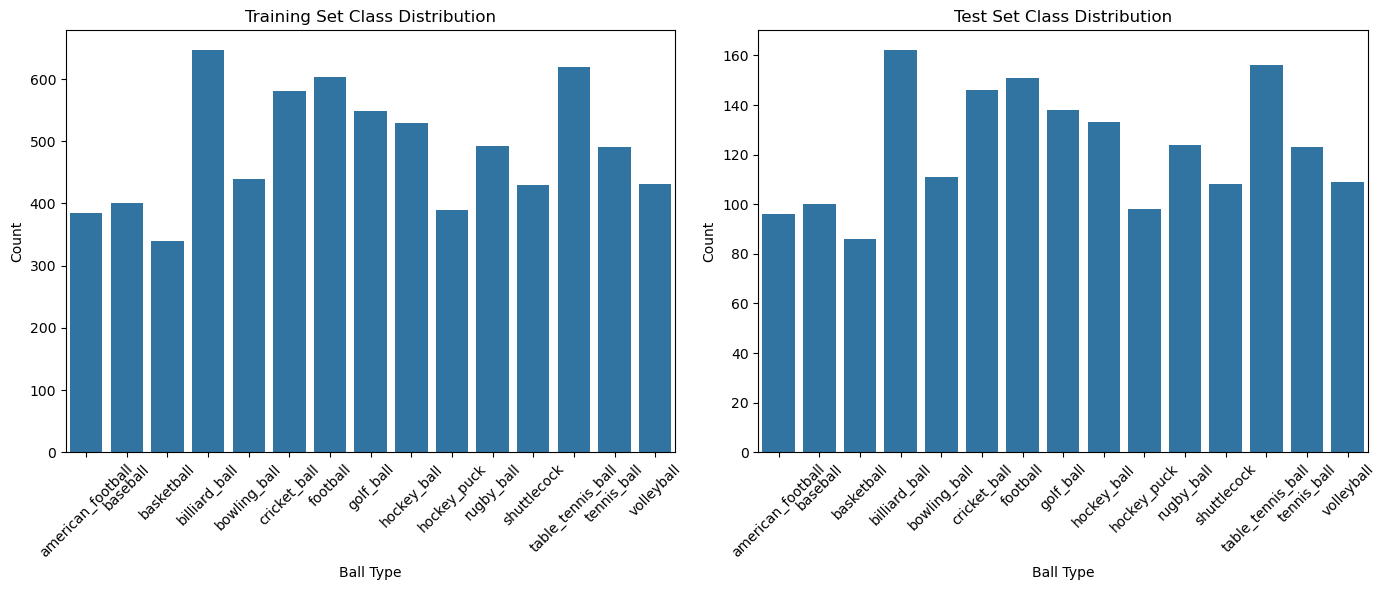

In [26]:
# Count the number of images per class in train and test sets
train_counts = np.unique(train_labels, return_counts=True)
test_counts = np.unique(test_labels, return_counts=True)

# Plot the distributions
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=train_counts[0], y=train_counts[1])
plt.title('Training Set Class Distribution')
plt.xlabel('Ball Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x=test_counts[0], y=test_counts[1])
plt.title('Test Set Class Distribution')
plt.xlabel('Ball Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Learning Curve
This plot shows the model’s accuracy on the training and validation sets as the size of the training set increases.
This helps to understand if the model is underfitting, overfitting, or has potential for improvement.

[learning_curve] Training set sizes: [ 586 1905 3224 4543 5862]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:  1.7min finished


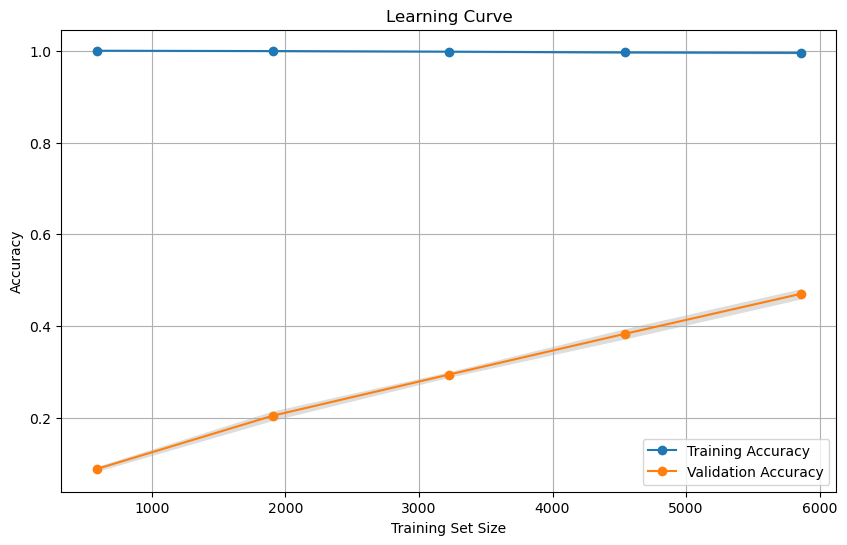

In [28]:

# Compute the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel='poly', C=1, degree=5, gamma='scale', coef0=1),  
    train_images_pca, train_labels_encoded, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy', 
    n_jobs=-1,  # Use all available processors
    train_sizes=np.linspace(0.1, 1.0, 5),  # Use 10%, 25%, 50%, 75%, and 100% of training data
    verbose = 1
)

# Calculate the mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', marker='o')
plt.plot(train_sizes, test_scores_mean, label='Validation Accuracy', marker='o')

# Add shaded areas for standard deviation
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, color = '#DDDDDD')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, color = '#DDDDDD')

# Plot formatting
plt.title('Learning Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

###  Precision-Recall Curve (for each Class)
For each class, this curve shows the trade-off between precision (correct positive predictions among all positive predictions) and recall (correct positive predictions among all actual positives) at different decision thresholds.
This curve helps evaluate the model’s performance on each class, particularly for imbalanced datasets. High precision indicates fewer false positives, while high recall indicates fewer false negatives.

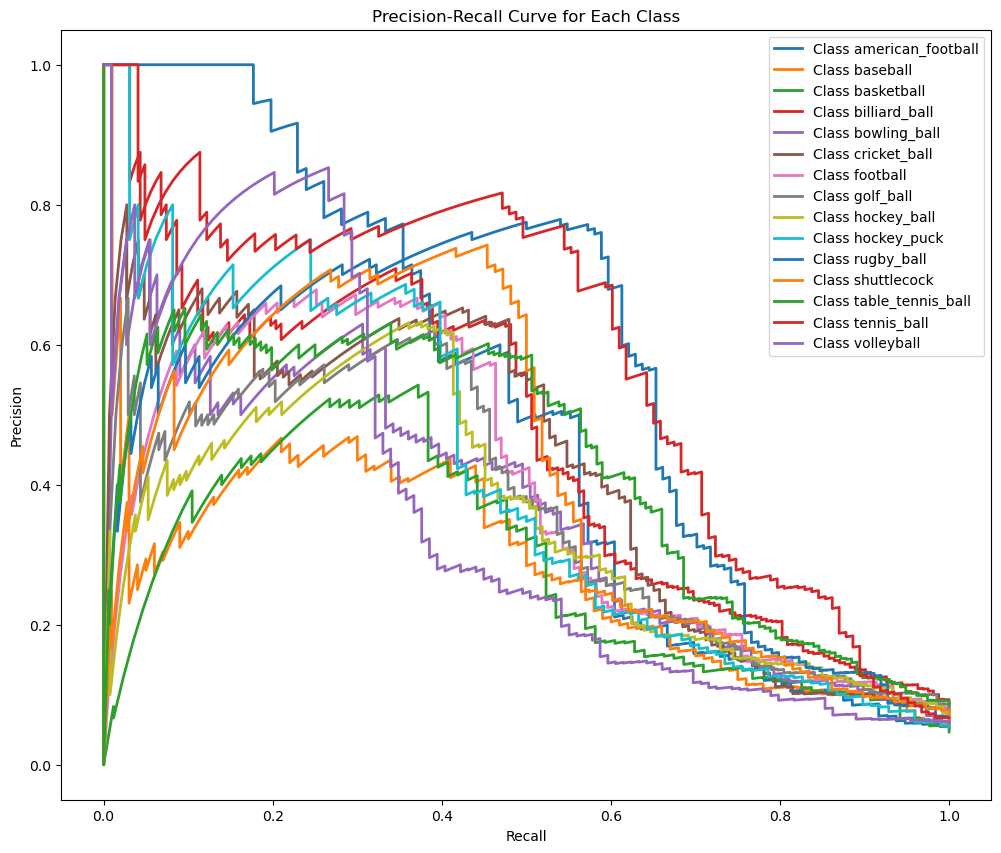

In [30]:
# Binarize labels for precision-recall curve plotting
y_test_bin = label_binarize(test_labels_encoded, classes=np.arange(len(np.unique(test_labels_encoded))))
y_scores = svm_model.decision_function(test_images_pca)  # decision_function gives scores to plot precision-recall

plt.figure(figsize=(12, 10))
for i in range(len(np.unique(test_labels_encoded))):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {label_encoder.inverse_transform([i])[0]}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc='best')
plt.show()